<a href="https://colab.research.google.com/github/summerof69/experimentation-synthetic-control/blob/main/notebooks/scm_sdid_notebook_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Control and Synthetic DiD: a hands-on notebook

By: Harendra Sahu

**Pre Read Notes:**
- Library Dependency: numpy, scipy, pandas, and matplotlib.
- All the data in this notebook is simulated or fictional.
- Sales are weekly, in Rs lakh.

**Contents**
1. The Pune free-delivery example by hand (before vs. after, control city, Synthetic Control)
2. Validation: RMSPE, the RMSPE ratio
3. Simulated data and the placebo test
4. Synthetic DiD: the same Pune example, then a big city where Synthetic Control fails
5. Side-by-side summary

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
BLUE, ORANGE, GREY, TEAL = "#2563EB", "#D97706", "#9AA3AF", "#0F9D8A"

def simplex_least_squares(X, y, ridge=0.0):
    """Find weights w >= 0 that add up to 1, minimising ||y - X w||^2 + ridge * ||w||^2."""
    n = X.shape[1]
    loss = lambda w: np.sum((y - X @ w) ** 2) + ridge * np.sum(w ** 2)
    res = minimize(loss, np.ones(n) / n, method="SLSQP", bounds=[(0, 1)] * n,
                   constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return res.x
print("Setup done")

Setup done


## 1.The Pune free-delivery example by hand

- FreshKart (fictional) launches free delivery in Pune in weeks 6 to 8.
- Weeks 1 to 5 are the "before" period. Nagpur, Indore and Surat had no campaign.

In [2]:
df = pd.DataFrame({
    "Week":   [f"W{i}" for i in range(1, 9)],
    "Pune":   [101, 99, 112, 110, 119, 125, 133, 138],
    "Nagpur": [110, 104, 120, 116, 130, 124, 130, 136],
    "Indore": [90, 100, 100, 110, 110, 110, 120, 120],
    "Surat":  [90, 90, 100, 100, 110, 100, 110, 110],
})
N_PRE = 5
pune = df["Pune"].values.astype(float)
donors = df[["Nagpur", "Indore", "Surat"]].values.astype(float)
df

,Week,Pune,Nagpur,Indore,Surat
0,W1,101,110,90,90
1,W2,99,104,100,90
2,W3,112,120,100,100
3,W4,110,116,110,100
4,W5,119,130,110,110
5,W6,125,124,110,100
6,W7,133,130,120,110
7,W8,138,136,120,110


### Method 1: Before vs. After (ignores market growth)

In [3]:
before, after = pune[:N_PRE].mean(), pune[N_PRE:].mean()
print(f"Pune before avg = {before:.1f}, campaign avg = {after:.1f}")
print(f"Before vs. after lift = {100 * (after / before - 1):.1f}%   (overstated)")

Pune before avg = 108.2, campaign avg = 132.0
Before vs. after lift = 22.0%   (overstated)


### Method 2: One control city (Difference-in-Differences with Nagpur)

In [4]:
nagpur = donors[:, 0]
gap = (pune[:N_PRE] - nagpur[:N_PRE])
print("Pre-launch gaps (Pune minus Nagpur):", gap, " average =", gap.mean())
control_cf = nagpur + gap.mean()                      # Nagpur adjusted for the usual gap
lift = pune[N_PRE:] - control_cf[N_PRE:]
print("Counterfactual W6-W8:", control_cf[N_PRE:].round(1))
print(f"Incremental sales = {lift.sum():.1f} lakh, lift = {100 * lift.sum() / control_cf[N_PRE:].sum():.1f}%")

Pre-launch gaps (Pune minus Nagpur): [ -9.  -5.  -8.  -6. -11.]  average = -7.8
Counterfactual W6-W8: [116.2 122.2 128.2]
Incremental sales = 29.4 lakh, lift = 8.0%


### Method 3:Synthetic Control

First with the neat 50/30/20 weights used in the blog (easy to verify by hand). Then we let the optimiser find its own weights.

In [5]:
w_blog = np.array([0.5, 0.3, 0.2])
synth_blog = donors @ w_blog
lift = pune[N_PRE:] - synth_blog[N_PRE:]
print("Synthetic Pune (50/30/20):", synth_blog)
print(f"Incremental sales = {lift.sum():.1f} lakh, lift = {100 * lift.sum() / synth_blog[N_PRE:].sum():.1f}%")

w_opt = simplex_least_squares(donors[:N_PRE], pune[:N_PRE])
synth_opt = donors @ w_opt
lift_opt = pune[N_PRE:] - synth_opt[N_PRE:]
print("\nOptimiser weights (Nagpur, Indore, Surat):", w_opt.round(2))
print(f"Incremental sales = {lift_opt.sum():.1f} lakh, lift = {100 * lift_opt.sum() / synth_opt[N_PRE:].sum():.1f}%")
print("Note: with only 5 pre-weeks and 3 donors the weights are not stable. Real tests use 52+ weeks.")

Synthetic Pune (50/30/20): [100. 100. 110. 111. 120. 115. 123. 126.]
Incremental sales = 32.0 lakh, lift = 8.8%

Optimiser weights (Nagpur, Indore, Surat): [0.53 0.15 0.32]
Incremental sales = 34.2 lakh, lift = 9.4%
Note: with only 5 pre-weeks and 3 donors the weights are not stable. Real tests use 52+ weeks.


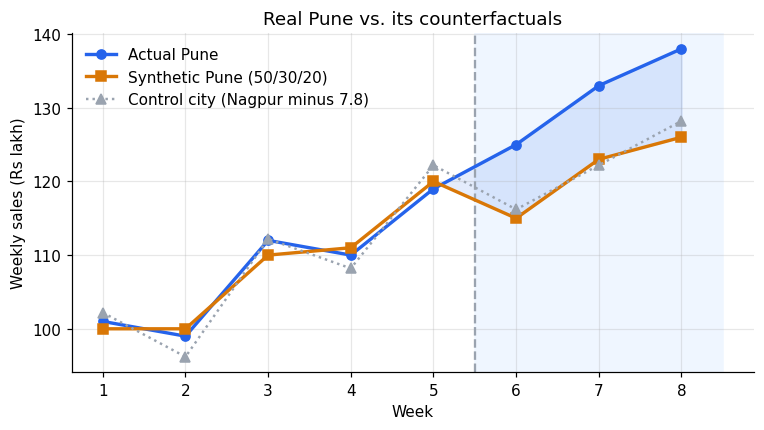

In [6]:
weeks = np.arange(1, 9)
fig, ax = plt.subplots(figsize=(8, 4))
ax.axvspan(5.5, 8.5, color="#EFF6FF"); ax.axvline(5.5, color=GREY, ls="--")
ax.plot(weeks, pune, color=BLUE, marker="o", lw=2.2, label="Actual Pune")
ax.plot(weeks, synth_blog, color=ORANGE, marker="s", lw=2.2, label="Synthetic Pune (50/30/20)")
ax.plot(weeks, control_cf, color=GREY, marker="^", lw=1.6, ls=":", label="Control city (Nagpur minus 7.8)")
ax.fill_between(weeks[N_PRE-1:], synth_blog[N_PRE-1:], pune[N_PRE-1:], color=BLUE, alpha=0.12)
ax.set_xlabel("Week"); ax.set_ylabel("Weekly sales (Rs lakh)"); ax.set_title("Real Pune vs. its counterfactuals")
ax.legend(frameon=False); plt.show()

## 2.Validation: RMSPE and the RMSPE ratio

`RMSPE = sqrt( average of (Actual - Predicted)^2 )`: the typical size of the model's miss in a normal week, in the same units as sales.

In [7]:
def rmspe(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

pre_syn  = rmspe(pune[:N_PRE], synth_blog[:N_PRE])
pre_ctl  = rmspe(pune[:N_PRE], control_cf[:N_PRE])
post_syn = rmspe(pune[N_PRE:], synth_blog[N_PRE:])
avg_pre_sales = pune[:N_PRE].mean()

print(f"Pre-launch RMSPE, synthetic control : {pre_syn:.2f}")
print(f"Pre-launch RMSPE, single control    : {pre_ctl:.2f}   -> synthetic is {100 * (1 - pre_syn / pre_ctl):.0f}% more accurate")
print(f"Pre-launch RMSPE as % of avg sales  : {100 * pre_syn / avg_pre_sales:.1f}%   (average weekly sales = {avg_pre_sales:.1f})")
print(f"Post-launch RMSPE                   : {post_syn:.2f}")
print(f"RMSPE ratio (post / pre)            : {post_syn / pre_syn:.1f}")
mape = np.mean(np.abs(pune[:N_PRE] - synth_blog[:N_PRE]) / pune[:N_PRE])
print(f"MAPE (avg % miss per week)          : {100 * mape:.1f}%")

Pre-launch RMSPE, synthetic control : 1.26
Pre-launch RMSPE, single control    : 2.14   -> synthetic is 41% more accurate
Pre-launch RMSPE as % of avg sales  : 1.2%   (average weekly sales = 108.2)
Post-launch RMSPE                   : 10.71
RMSPE ratio (post / pre)            : 8.5
MAPE (avg % miss per week)          : 1.1%


## 3.Simulated data and the placebo test

Now a realistic setup: 25 donor cities, 52 pre-weeks, 8 post-weeks, a shared market trend with seasonality and a festival bump, and a true campaign lift of 8%.

In [8]:
def simulate(test_level, true_lift=0.08, seed=7, J=25, n_pre=52, n_post=8):
    rng = np.random.default_rng(seed)
    T = n_pre + n_post
    t = np.arange(T)
    market = 0.25 * t + 12 * np.sin(2 * np.pi * t / 52)       # shared trend + season
    market[44:48] += 10                                        # festival bump
    levels = rng.uniform(60, 110, J)                           # donor sizes
    loads = rng.normal(1.0, 0.15, J)                           # sensitivity to the market
    donors = levels + np.outer(market, loads) + rng.normal(0, 1.2, (T, J))
    test = test_level + market + rng.normal(0, 1.2, T)
    clean = test.copy()
    test[n_pre:] *= (1 + true_lift)                            # the campaign effect
    return test, donors, clean, n_pre

def synthetic_control(y_test, Y_donors, n_pre):
    w = simplex_least_squares(Y_donors[:n_pre], y_test[:n_pre])
    synthetic = Y_donors @ w
    return w, synthetic, y_test[n_pre:] - synthetic[n_pre:]

y, D, clean, n_pre = simulate(test_level=85)       # a Pune-like city inside the donor range
w, synth, lift = synthetic_control(y, D, n_pre)
print(f"True lift: 8.0%   |   Synthetic Control estimate: {100 * lift.sum() / synth[n_pre:].sum():.1f}%")
print(f"Pre-launch RMSPE: {rmspe(y[:n_pre], synth[:n_pre]):.2f}")
top = np.argsort(w)[::-1][:5]
print("Top donor weights:", {f'donor {i}': round(float(w[i]), 2) for i in top})

True lift: 8.0%   |   Synthetic Control estimate: 8.0%
Pre-launch RMSPE: 1.00
Top donor weights: {'donor 5': 0.24, 'donor 14': 0.18, 'donor 23': 0.18, 'donor 24': 0.12, 'donor 19': 0.11}


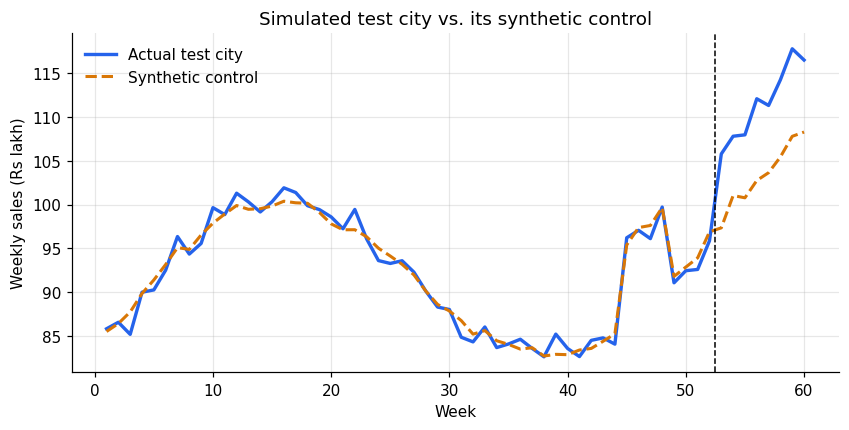

In [9]:
x = np.arange(1, len(y) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, color=BLUE, lw=2.2, label="Actual test city")
ax.plot(x, synth, color=ORANGE, lw=2, ls="--", label="Synthetic control")
ax.axvline(n_pre + 0.5, color="k", ls="--", lw=1)
ax.set_xlabel("Week"); ax.set_ylabel("Weekly sales (Rs lakh)"); ax.set_title("Simulated test city vs. its synthetic control")
ax.legend(frameon=False); plt.show()

### The Placebo test

For **every** donor city: pretend it was treated, build its synthetic version from the **other 24 donors** (never the real test city), and compute its RMSPE ratio. Then rank the real test city among all 26 ratios.

`p = rank / (number of donors + 1)`

In [10]:
def gap_and_ratio(target, donors_, n_pre):
    _, s, _ = synthetic_control(target, donors_, n_pre)
    g = target - s
    pre = np.sqrt(np.mean(g[:n_pre] ** 2)); post = np.sqrt(np.mean(g[n_pre:] ** 2))
    return g, post / pre

gap_test, ratio_test = gap_and_ratio(y, D, n_pre)
placebo_gaps, placebo_ratios = [], []
for j in range(D.shape[1]):                                  # 25 placebo runs
    g, r = gap_and_ratio(D[:, j], np.delete(D, j, axis=1), n_pre)   # other 24 donors
    placebo_gaps.append(g); placebo_ratios.append(r)

rank = 1 + sum(r > ratio_test for r in placebo_ratios)
n_cities = len(placebo_ratios) + 1
print(f"Test city RMSPE ratio : {ratio_test:.1f}")
print(f"Largest placebo ratio : {max(placebo_ratios):.1f}")
print(f"Rank of test city     : {rank} of {n_cities}")
print(f"p-value               : {rank} / {n_cities} = {rank / n_cities:.3f}")

Test city RMSPE ratio : 8.3
Largest placebo ratio : 1.9
Rank of test city     : 1 of 26
p-value               : 1 / 26 = 0.038


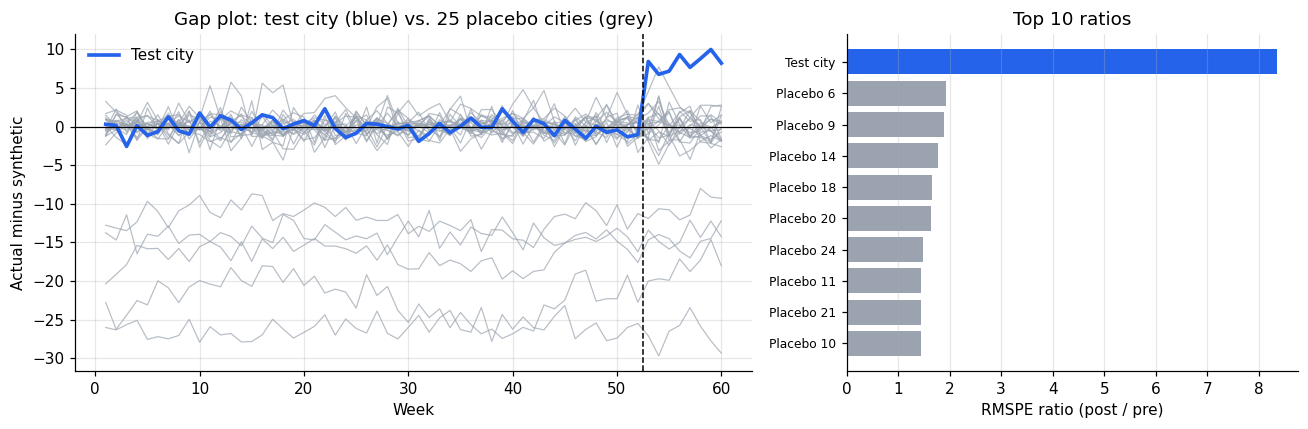

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.5, 1]})
for g in placebo_gaps: a1.plot(x, g, color=GREY, lw=0.8, alpha=0.7)
a1.plot(x, gap_test, color=BLUE, lw=2.4, label="Test city")
a1.axvline(n_pre + 0.5, color="k", ls="--", lw=1); a1.axhline(0, color="k", lw=0.8)
a1.set_xlabel("Week"); a1.set_ylabel("Actual minus synthetic"); a1.set_title("Gap plot: test city (blue) vs. 25 placebo cities (grey)")
a1.legend(frameon=False)
allr = [ratio_test] + placebo_ratios
order = np.argsort(allr)[::-1][:10]
a2.barh(range(10)[::-1], [allr[i] for i in order], color=[BLUE if i == 0 else GREY for i in order])
a2.set_yticks(range(10)[::-1]); a2.set_yticklabels(["Test city" if i == 0 else f"Placebo {i}" for i in order], fontsize=8)
a2.set_xlabel("RMSPE ratio (post / pre)"); a2.set_title("Top 10 ratios"); a2.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### Additional Test: Leave-one-out check

Remove the top-weighted donor and refit. The lift should barely move.

In [12]:
for k in np.argsort(w)[::-1][:3]:
    D_loo = np.delete(D, k, axis=1)
    _, s_loo, l_loo = synthetic_control(y, D_loo, n_pre)
    print(f"Dropping donor {k} (weight {w[k]:.2f}): lift = {100 * l_loo.sum() / s_loo[n_pre:].sum():.1f}%")

Dropping donor 5 (weight 0.24): lift = 7.8%
Dropping donor 14 (weight 0.18): lift = 8.1%
Dropping donor 23 (weight 0.18): lift = 8.0%


## 4.Synthetic DiD

Three upgrades over Synthetic Control: an **intercept** (absorbs size differences), a **ridge penalty** (spreads weights across more cities), and **time weights** (picks the most relevant pre-weeks). The effect is a weighted double difference.

In [13]:
def synthetic_did(y_test, Y_donors, n_pre):
    pre_d, post_d = Y_donors[:n_pre], Y_donors[n_pre:]
    pre_t, post_t = y_test[:n_pre], y_test[n_pre:]

    # 1. City weights. Centring each series over time removes the level (the intercept).
    sigma = np.std(np.diff(pre_d, axis=0))
    zeta2 = (len(post_t) ** 0.25 * sigma) ** 2               # ridge strength
    omega = simplex_least_squares(pre_d - pre_d.mean(0), pre_t - pre_t.mean(), ridge=zeta2 * n_pre)
    intercept = (pre_t - pre_d @ omega).mean()

    # 2. Week weights. Flip the table: cities as rows, weeks as columns.
    X, target = pre_d.T, post_d.mean(0)
    lam = simplex_least_squares(X - X.mean(0), target - target.mean(), ridge=1e-6)

    # 3. Weighted double difference.
    test_change  = post_t.mean() - lam @ pre_t
    synth_change = post_d.mean(0) @ omega - lam @ (pre_d @ omega)
    tau = test_change - synth_change                         # average weekly lift
    counterfactual = post_d @ omega + (lam @ pre_t - lam @ (pre_d @ omega))
    return omega, lam, intercept, tau, counterfactual
print("synthetic_did defined")

synthetic_did defined


### 4a.The Pune example by hand as SDID

Keep the 50/30/20 city weights and use **illustrative** time weights of 40% on W4 and 60% on W5 (the most recent weeks).

In [14]:
lam_h = np.array([0, 0, 0, 0.4, 0.6])
synth_pre = synth_blog[:N_PRE]
w_before_actual = lam_h @ pune[:N_PRE]
w_before_synth  = lam_h @ synth_pre
after_actual, after_synth = pune[N_PRE:].mean(), synth_blog[N_PRE:].mean()

print(f"Actual Pune   : weighted before = {w_before_actual:.1f}, after = {after_actual:.1f}, change = {after_actual - w_before_actual:+.1f}")
print(f"Synthetic Pune: weighted before = {w_before_synth:.1f}, after = {after_synth:.1f}, change = {after_synth - w_before_synth:+.1f}")
tau_h = (after_actual - w_before_actual) - (after_synth - w_before_synth)
pre_gap = lam_h @ (pune[:N_PRE] - synth_pre)
cf_h = synth_blog[N_PRE:] + pre_gap
print(f"\nDouble difference (weekly lift) = {tau_h:+.1f}")
print(f"Counterfactual W6-W8 = synthetic + {pre_gap:+.1f} -> {cf_h}")
print(f"Incremental sales = {pune[N_PRE:].sum() - cf_h.sum():.0f} lakh, lift = {100 * (pune[N_PRE:].sum() - cf_h.sum()) / cf_h.sum():.1f}%")
print("Compare: Synthetic Control gave 32 lakh / 8.8%")

Actual Pune   : weighted before = 115.4, after = 132.0, change = +16.6
Synthetic Pune: weighted before = 116.4, after = 121.3, change = +4.9

Double difference (weekly lift) = +11.7
Counterfactual W6-W8 = synthetic + -1.0 -> [114. 122. 125.]
Incremental sales = 35 lakh, lift = 9.7%
Compare: Synthetic Control gave 32 lakh / 8.8%


### 4b.When the test city is bigger than every donor

Now a Bengaluru-like city (level 150) against donors of 60 to 110. Synthetic Control can only blend donors, so it cannot reach the test city. SDID's intercept absorbs the size gap.

In [15]:
y2, D2, clean2, n_pre = simulate(test_level=150)
w2, synth2, lift2 = synthetic_control(y2, D2, n_pre)
omega, lam, b, tau, cf = synthetic_did(y2, D2, n_pre)

scm_pct  = 100 * lift2.sum() / synth2[n_pre:].sum()
sdid_pct = 100 * tau * len(cf) / cf.sum()
print(f"True lift: 8.0%")
print(f"Synthetic Control : {scm_pct:.1f}%   (pre-launch RMSPE = {rmspe(y2[:n_pre], synth2[:n_pre]):.1f})")
print(f"Synthetic DiD     : {sdid_pct:.1f}%")
print("\nSCM top weights :", np.sort(w2)[::-1][:4].round(2), "  <- all on one donor")
print("SDID top weights:", np.sort(omega)[::-1][:4].round(2), "  <- spread out by the ridge penalty")

True lift: 8.0%
Synthetic Control : 37.9%   (pre-launch RMSPE = 39.0)
Synthetic DiD     : 7.9%

SCM top weights : [1. 0. 0. 0.]   <- all on one donor
SDID top weights: [0.06 0.06 0.06 0.05]   <- spread out by the ridge penalty


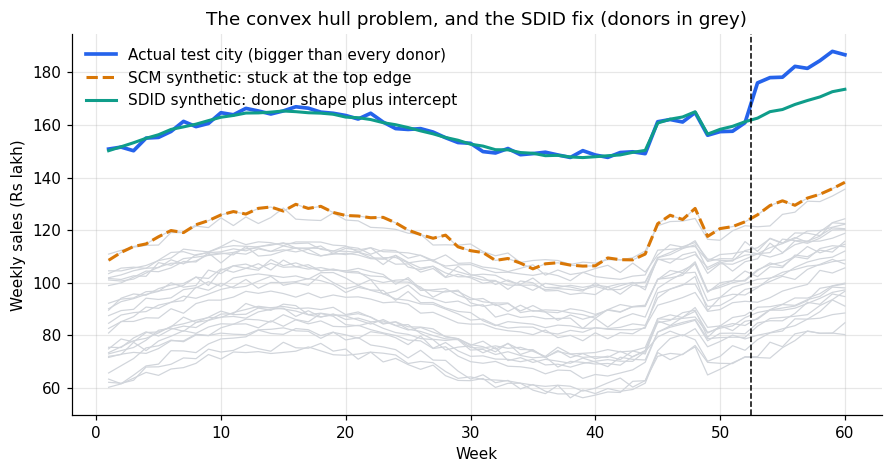

In [16]:
x2 = np.arange(1, len(y2) + 1)
sdid_line = D2 @ omega + b
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for j in range(D2.shape[1]): ax.plot(x2, D2[:, j], color="#D1D5DB", lw=0.8)
ax.plot(x2, y2, color=BLUE, lw=2.4, label="Actual test city (bigger than every donor)")
ax.plot(x2, synth2, color=ORANGE, lw=2, ls="--", label="SCM synthetic: stuck at the top edge")
ax.plot(x2, sdid_line, color=TEAL, lw=2, label="SDID synthetic: donor shape plus intercept")
ax.axvline(n_pre + 0.5, color="k", ls="--", lw=1)
ax.set_xlabel("Week"); ax.set_ylabel("Weekly sales (Rs lakh)"); ax.set_title("The convex hull problem, and the SDID fix (donors in grey)")
ax.legend(frameon=False, loc="upper left"); plt.show()

### SDID time weights

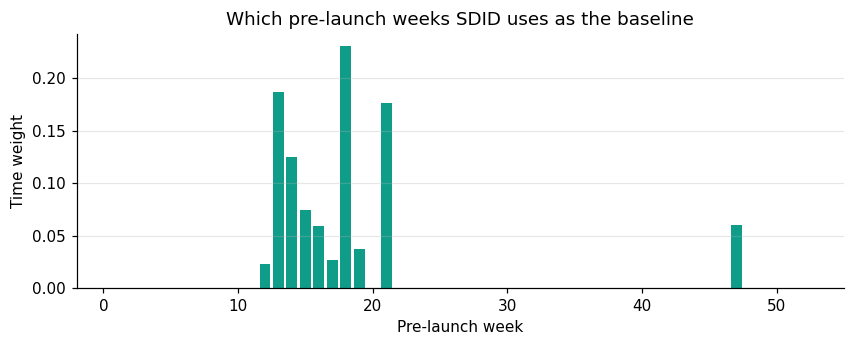

Weeks with the most weight: [18, 13, 21, 14, 15] -> check these weeks were 'normal'


In [17]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(np.arange(1, n_pre + 1), lam, color=TEAL)
ax.set_xlabel("Pre-launch week"); ax.set_ylabel("Time weight"); ax.set_title("Which pre-launch weeks SDID uses as the baseline")
ax.grid(axis="x", visible=False); plt.show()
print("Weeks with the most weight:", (np.argsort(lam)[::-1][:5] + 1).tolist(), "-> check these weeks were 'normal'")

## 5.Side-by-side summary

In [19]:
def compare(level, label):
    yy, DD, cc, n = simulate(level)
    _, s, l = synthetic_control(yy, DD, n)
    _, _, _, t, c = synthetic_did(yy, DD, n)
    ctrl = DD[:, 0]
    did = yy[n:] - (ctrl[n:] + (yy[:n] - ctrl[:n]).mean())
    return {"Scenario": label, "True lift %": 8.0,
            "Synthetic Control %": round(100 * l.sum() / s[n:].sum(), 1),
            "Synthetic DiD %": round(100 * t * len(c) / c.sum(), 1),
            "One-city DiD %": round(100 * did.sum() / (yy[n:].sum() - did.sum()), 1)}

pd.DataFrame([compare(85, "Test city inside donor range"), compare(150, "Test city bigger than all donors")])

,Scenario,True lift %,Synthetic Control %,Synthetic DiD %,One-city DiD %
0,Test city inside donor range,8.0,8.0,7.8,8.1
1,Test city bigger than all donors,8.0,37.9,7.9,8.1


**What to take away**

- When the test city sits inside the donor range, all methods agree.
- When the test city is bigger than every donor, Synthetic Control is fooled by a poor pre-launch fit, while SDID holds.
- Run several methods side by side. Agreement builds confidence, and disagreement tells you something about your data.
- The one-city DiD looks fine here only because this simulation is simple and the single control city happens to track well. Never rely on one hand-picked control.